# Introducción al Aprendizaje No Supervisado

_Casos de uso, familias de algoritmos y diferencias con el aprendizaje supervisado_

**Módulo 2 — Aprendizaje No Supervisado** | DSRP Machine Learning Engineering
**Profesor:** Miguel Arquez

![Aprendizaje No Supervisado](assets/header.png)

## 1. ¿Qué es el aprendizaje no supervisado?

A diferencia del supervisado, aquí **no tenemos etiquetas** $y$. Solo disponemos de observaciones $x_1, x_2, \dots, x_n$ y queremos descubrir **estructura** dentro de los datos:

$$
\text{Datos: } X \in \mathbb{R}^{n \times p} \quad\Rightarrow\quad \text{Estructura: grupos, ejes, asociaciones, anomalías}
$$

**Idea clave:** no le decimos al modelo qué tiene que aprender; el modelo busca patrones por sí mismo. Por eso la evaluación es más subjetiva (no hay un "accuracy" universal).

| | Supervisado | No supervisado |
|---|---|---|
| Tenemos $y$ | sí | no |
| Pregunta típica | "¿cuánto vale?", "¿de qué clase es?" | "¿qué grupos hay?", "¿qué ejes resumen los datos?" |
| Métricas | MAE, F1, AUC… (objetivas) | silhouette, varianza explicada… (heurísticas) |
| Ejemplos | regresión, clasificación | clustering, PCA, reglas de asociación |

### Pipeline típico

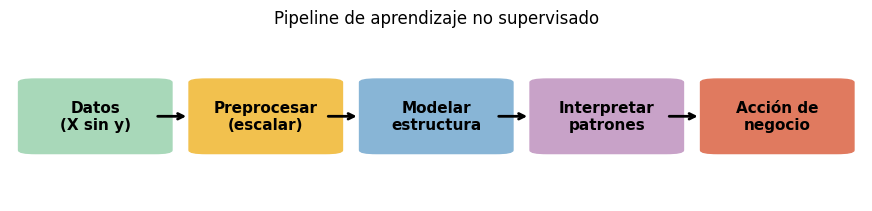

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(11, 2.2))
etapas = [
    ('Datos\n(X sin y)',     '#A8D8B9'),
    ('Preprocesar\n(escalar)', '#F2C14E'),
    ('Modelar\nestructura',  '#88B5D6'),
    ('Interpretar\npatrones', '#C8A2C8'),
    ('Acción de\nnegocio',   '#E07A5F'),
]
xs = np.linspace(0.03, 0.83, len(etapas))
for x, (txt, c) in zip(xs, etapas):
    ax.add_patch(patches.FancyBboxPatch(
        (x, 0.3), 0.14, 0.4, boxstyle='round,pad=0.02', color=c,
    ))
    ax.text(x + 0.07, 0.5, txt, ha='center', va='center',
            fontsize=11, fontweight='bold')
for x in xs[:-1]:
    ax.annotate('', xy=(x + 0.18, 0.5), xytext=(x + 0.14, 0.5),
                arrowprops={'arrowstyle': '->', 'lw': 2})
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('Pipeline de aprendizaje no supervisado', fontsize=12)
plt.show()

## 2. Familias de problemas

| Familia | Pregunta que responde | Algoritmos típicos |
|---|---|---|
| **Clustering** | ¿Qué grupos naturales existen? | K-Means, Hierarchical, DBSCAN, GMM |
| **Reducción de dimensionalidad** | ¿Qué pocos ejes resumen los datos? | PCA, t-SNE, UMAP, autoencoders |
| **Reglas de asociación** | ¿Qué cosas ocurren juntas? | Apriori, FP-Growth |
| **Detección de anomalías** | ¿Qué observaciones son raras? | Isolation Forest, One-Class SVM, LOF |
| **Modelado de densidad** | ¿Cuál es la distribución de los datos? | KDE, GMM, modelos generativos |

En este módulo cubrimos las tres primeras familias:
- **Clustering** — notebook 02 (K-Means y jerárquico).
- **Reducción de dimensionalidad** — notebook 03 (PCA + visualización de clusters).
- **Reglas de asociación** — notebook 04 (Apriori, soporte, confianza, lift).

## 3. Casos de uso reales

- **Marketing**: segmentación de clientes para campañas dirigidas, perfiles de comportamiento.
- **Retail**: análisis de canasta de mercado ("quien compra pan también compra mantequilla").
- **Finanzas**: detección de fraude (patrones anómalos), perfiles de riesgo.
- **Salud**: agrupamiento de pacientes con síntomas similares, descubrimiento de subtipos de enfermedad.
- **Visión / NLP**: compresión y visualización de embeddings de alta dimensión.
- **Industria**: detección de fallas en sensores antes de que ocurra una avería.

## 4. ¿Por qué es más difícil evaluar?

En supervisado tenemos un "ground truth" $y$ contra el cual comparar. En no supervisado **no existe respuesta correcta única**: dos analistas pueden encontrar agrupamientos distintos y ambos ser válidos. Por eso usamos:

- **Métricas internas** — miden qué tan compactos y separados son los grupos sin usar etiquetas:
  - **Silhouette** $s \in [-1, 1]$: cercano a 1 si los puntos están bien agrupados.
  - **Davies-Bouldin** y **Calinski-Harabasz**.
  - **Inercia** (suma de distancias al centroide) para K-Means.
- **Métricas externas** (cuando _por excepción_ tenemos etiquetas para validar):
  - **Adjusted Rand Index (ARI)**, **Normalized Mutual Information (NMI)**.
- **Validación de negocio** — la más importante: ¿los segmentos son **accionables**? ¿Tienen sentido para marketing, riesgo, operaciones?

## 5. Importancia del preprocesamiento

Casi todos los algoritmos no supervisados son **sensibles a la escala** de las variables (porque dependen de distancias o de la covarianza). Pasos habituales:

1. **Escalar**: `StandardScaler` (media 0, varianza 1) o `MinMaxScaler` (rango 0–1).
2. **Codificar categóricas**: `OneHotEncoder` o agrupar y codificar como ordinal cuando tenga sentido.
3. **Tratar outliers**: pueden dominar las distancias y romper los clusters.
4. **Reducir dimensión** si $p$ es muy grande (PCA antes de clustering).

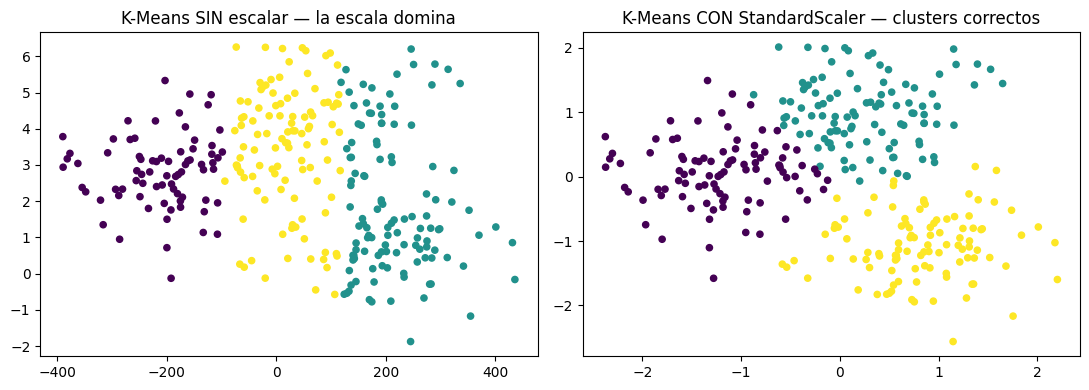

In [4]:
# Demo rápida: por qué hace falta escalar antes de clustear
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Generamos clusters bien separados, pero alteramos la escala de un eje
X, y_true = make_blobs(n_samples=300, centers=3, random_state=0)
X[:, 0] = X[:, 0] * 100   # x1 ahora vale ~100x más que x2

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X)
axes[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis', s=20)
axes[0].set_title('K-Means SIN escalar — la escala domina')

X_s = StandardScaler().fit_transform(X)
km_s = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_s)
axes[1].scatter(X_s[:, 0], X_s[:, 1], c=km_s.labels_, cmap='viridis', s=20)
axes[1].set_title('K-Means CON StandardScaler — clusters correctos')
plt.tight_layout(); plt.show()

## 6. Datasets que usaremos en el módulo

**1. Telco Customer Churn** _(notebooks 02 y 03)_
- URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
- Archivo: `WA_Fn-UseC_-Telco-Customer-Churn.csv` (7.043 × 21).
- Aunque trae la etiqueta `Churn`, en este módulo la **ignoramos** y usamos solo los predictores para descubrir segmentos de clientes. Al final podemos usar `Churn` como validación externa.

**2. Datos sintéticos de canasta de mercado** _(notebook 04)_
- Generaremos en el propio notebook un conjunto de transacciones con productos de supermercado (pan, leche, café, etc.). Es la forma estándar de enseñar reglas de asociación; en producción se usaría **Online Retail (UCI)** o el log transaccional propio.

**3. `make_blobs` y `make_moons`** _(intuición visual)_
- Datos sintéticos en 2D para visualizar el comportamiento de los algoritmos antes de aplicarlos al dataset real.

## 7. Referencias

- Hastie, T., Tibshirani, R. & Friedman, J. (2009). *The Elements of Statistical Learning*, cap. 14 (Unsupervised Learning).
- James, G. et al. (2021). *An Introduction to Statistical Learning* (ISLR), cap. 12. https://www.statlearning.com/
- Documentación scikit-learn — Unsupervised learning: https://scikit-learn.org/stable/unsupervised_learning.html
- Aggarwal, C. C. (2015). *Data Mining: The Textbook*.